## Evaluation of the Neural Additive Model (NAM) on the Housing dataset

In [15]:
import neural_additive_models.data_utils as data_utils
import neural_additive_models.graph_builder as graph_builder

import os.path as osp

In [16]:
from utils import load_col_min_max, inverse_min_max_scaler

In [17]:
dataset_name = 'Housing'
is_regression = dataset_name in ['Housing', 'Fico']
housing_data =  data_utils.load_dataset(dataset_name)
data_x, data_y, column_names = housing_data
col_min_max = load_col_min_max(dataset_name)

In [18]:
from sklearn.model_selection import KFold, StratifiedKFold

NUM_FOLDS = 5
fold_test_indices = []
fold_train_indices = []

if is_regression:
    kfold = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
else:
    kfold = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)

all_splits = list(kfold.split(data_x, data_y))

for fold_num in range(1, NUM_FOLDS + 1):
    train_idx, test_idx = all_splits[fold_num - 1]
    fold_train_indices.append(train_idx)
    fold_test_indices.append(test_idx)
    


In [19]:
from utils import prepare_feature_arrays, get_dataset_config, compute_mean_predictions

# Step 1: Prepare data
SINGLE_FEATURES_ORIGINAL, UNIQUE_FEATURES_ORIGINAL, UNIQUE_FEATURES = prepare_feature_arrays(
    data_x, column_names, col_min_max, inverse_min_max_scaler
)

# Step 2: Load dataset-specific config
COL_NAMES, FEATURE_LABEL_MAPPING, CATEGORICAL_NAMES = get_dataset_config(dataset_name, column_names)

In [20]:
import numpy as np
from utils import load_nam_checkpoint
from utils import get_test_predictions, compute_features, get_feature_predictions

all_preds_per_fold = [[] for _ in range(5)]
all_hist_data = []
all_mean_pred = []

for fold in range(1, 6):             # 5 folds
    fold_idx = fold - 1
    test_indices = fold_test_indices[fold_idx]
    print(f"Processing fold {fold} (test set size: {len(test_indices)})...")
    
    for split in range(1, 4):       # 3 splits per fold
        if split % 5 == 0:
            print(f"  Processing split {split}...")
        ckpt_dir = f"./housing_default/fold_{fold}/split_{split}/model_0/best_checkpoint"

        nam, sess = load_nam_checkpoint(ckpt_dir)
        
        # Get predictions on the FULL dataset (needed for feature importance plots)
        preds_full = get_test_predictions(nam, data_x.astype(np.float32), sess)
        
        # Store only test set predictions for RMSE calculation
        preds_test = preds_full[test_indices]
        all_preds_per_fold[fold_idx].append(preds_test)

        # For feature importance plots, we still need full dataset
        feature_predictions = get_feature_predictions(nam, dataset_name, sess)
        avg_hist_data, mean_pred, _ = compute_mean_predictions(
            data_x, column_names, UNIQUE_FEATURES, feature_predictions
        )

        all_hist_data.append(avg_hist_data)
        all_mean_pred.append(mean_pred)

Processing fold 1 (test set size: 4128)...
Using checkpoint: ./housing_default/fold_1/split_1/model_0/best_checkpoint\model.ckpt-6580
Feature widths: [1000, 104, 1000, 1000, 1000, 1000, 1000, 1000]
Num input features: 8
INFO:tensorflow:Restoring parameters from ./housing_default/fold_1/split_1/model_0/best_checkpoint\model.ckpt-6580
✅ Restored NAM from checkpoint.
Using checkpoint: ./housing_default/fold_1/split_2/model_0/best_checkpoint\model.ckpt-2800
Feature widths: [1000, 104, 1000, 1000, 1000, 1000, 1000, 1000]
Num input features: 8
INFO:tensorflow:Restoring parameters from ./housing_default/fold_1/split_2/model_0/best_checkpoint\model.ckpt-2800
✅ Restored NAM from checkpoint.
Using checkpoint: ./housing_default/fold_1/split_3/model_0/best_checkpoint\model.ckpt-4620
Feature widths: [1000, 104, 1000, 1000, 1000, 1000, 1000, 1000]
Num input features: 8
INFO:tensorflow:Restoring parameters from ./housing_default/fold_1/split_3/model_0/best_checkpoint\model.ckpt-4620
✅ Restored NAM fr

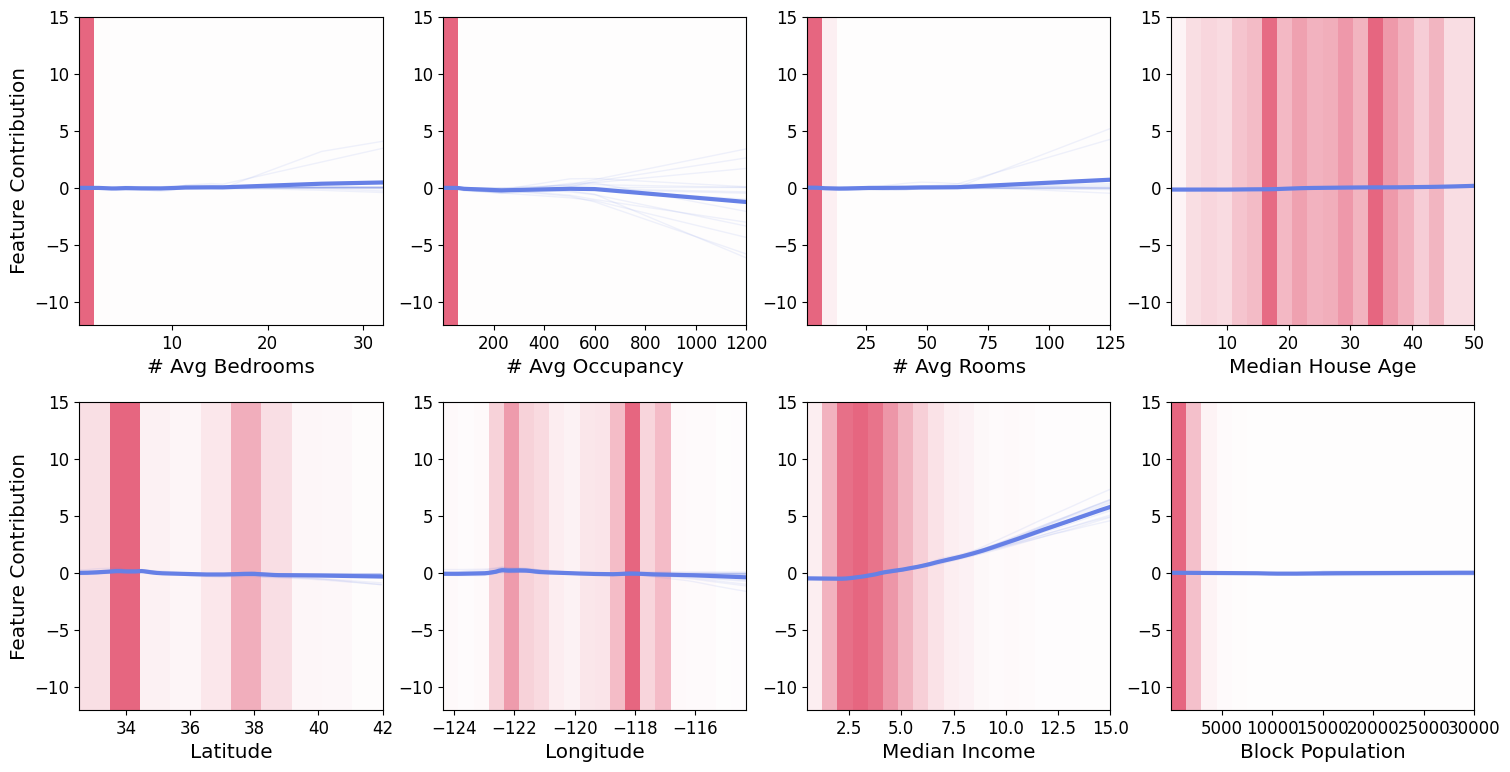

In [21]:
from utils import plot_nam_contributions_with_density


x_limits = {
    'MedInc': 15,
    'HouseAge': 50,
    'AveRooms': 125,
    'AveBedrms': 32,
    'Population': 30000,
    'AveOccup': 1200,
    'Latitude': 42,
}

y_limits = {
    'MedInc': (-12, 15),
    'HouseAge': (-12, 15),
    'AveRooms': (-12, 15),
    'AveBedrms': (-12, 15),
    'Population': (-12, 15),
    'AveOccup': (-12, 15),
    'Latitude': (-12, 15),
    'Longitude': (-12, 15)
}

fig = plot_nam_contributions_with_density(
    hist_data=all_hist_data,
    unique_features=UNIQUE_FEATURES_ORIGINAL,
    single_features=SINGLE_FEATURES_ORIGINAL,
    categorical_names=CATEGORICAL_NAMES,
    col_mapping=COL_NAMES[dataset_name],
    feature_mapping=FEATURE_LABEL_MAPPING[dataset_name],
    mean_pred=all_mean_pred,
    feature_to_use=column_names,
    x_limits=x_limits,
    y_limits=y_limits
)


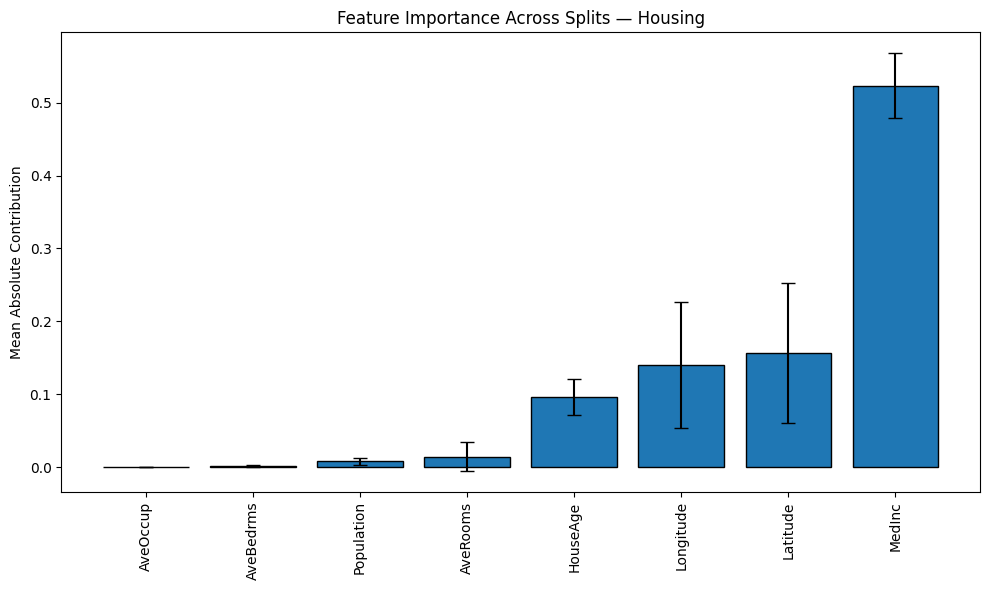

In [22]:
from utils import compute_mean_feature_importance
import numpy as np
import matplotlib.pyplot as plt

# Compute per-split importances
all_feature_importances = []

for avg_hist_data, mean_pred in zip(all_hist_data, all_mean_pred):
    feature_names, importances = compute_mean_feature_importance(avg_hist_data, mean_pred)
    all_feature_importances.append(importances)

# Combine into matrix (splits x features)
all_feature_importances = np.vstack(all_feature_importances)

# Average and std across splits
importance_mean = all_feature_importances.mean(axis=0)
importance_std  = all_feature_importances.std(axis=0)

# Sort features by mean importance
sorted_idx = np.argsort(importance_mean)
sorted_features = np.array(feature_names)[sorted_idx]
sorted_mean = importance_mean[sorted_idx]
sorted_std  = importance_std[sorted_idx]

# Plot averaged feature importance with error bars
plt.figure(figsize=(10, 6))
plt.bar(sorted_features, sorted_mean, yerr=sorted_std, capsize=5, edgecolor="k")
plt.xticks(rotation=90)
plt.ylabel("Mean Absolute Contribution")
plt.title(f"Feature Importance Across Splits — {dataset_name}")
plt.tight_layout()
plt.show()


In [23]:
fold_rmses = []

for fold_idx in range(5):
    # Get test set indices and labels for this fold
    test_indices = fold_test_indices[fold_idx]
    y_test_fold = data_y[test_indices]
    
    # Ensemble predictions
    preds = np.vstack(all_preds_per_fold[fold_idx])   # (20, n_test_samples)
    ensemble_pred = preds.mean(axis=0)
    
    # Compute RMSE only on test set
    rmse = graph_builder.calculate_metric(
        y_test_fold,
        ensemble_pred,
        regression=True
    )
    fold_rmses.append(rmse)
    print(f"Fold {fold_idx+1} RMSE (test set only): {rmse:.4f} (n={len(test_indices)})")

fold_rmses = np.array(fold_rmses)
avg_rmse = fold_rmses.mean()
std_rmse = fold_rmses.std()

print(f"\nAverage Ensemble RMSE across folds (test sets only): {avg_rmse:.4f}")
print(f"Std of Ensemble RMSE across folds: {std_rmse:.4f}")


Fold 1 RMSE (test set only): 0.9244 (n=4128)
Fold 2 RMSE (test set only): 0.8796 (n=4128)
Fold 3 RMSE (test set only): 0.8871 (n=4128)
Fold 4 RMSE (test set only): 0.8672 (n=4128)
Fold 5 RMSE (test set only): 0.8633 (n=4128)

Average Ensemble RMSE across folds (test sets only): 0.8843
Std of Ensemble RMSE across folds: 0.0218
